# 05 — Content-Hash Reprocessing / Dedup Demo

Companion notebook to `06-document-reprocessing-and-citation-deduplication.md`. Referenced directly
from `99-Interview-QA.md` Q2: *"`notebooks/05_content_hash_reprocessing_demo.ipynb` runs the
exact-hash/perceptual-hash/supersede logic end to end against synthetic images."*

This notebook implements chapter 06 Part 4's proposed pre-pipeline dedup check exactly as specified
there: an **exact SHA-256 hash** of the raw input bytes to catch true duplicate re-uploads, a
**perceptual (difference) hash** tolerant of a corrected re-scan's cosmetic changes (recompression, a
brightness shift, a slight deskew jitter) to flag likely revisions, and a `check_for_reprocessing()`
function with the same three-way `{skip_exact_duplicate, supersede, process_new}` decision the
chapter's own code block defines. Section 6 also implements the chapter's `source_document_version`
schema field and the "flip the prior citation record to `superseded`, never delete it" behavior.

Fully offline: numpy and PIL only — no real model downloads, no real OCR/YOLO/CNN calls (those are
covered elsewhere in this course; this notebook is entirely about the dedup layer that would sit
*ahead* of them). All documents here are synthetic images generated with `PIL.ImageDraw`.

In [1]:
import hashlib

import numpy as np
from PIL import Image, ImageDraw, ImageFont

print("Imports OK")

Imports OK


## Step 1 — A synthetic document generator

Stands in for a real slide/scan image: a white canvas with one line of claim text rendered on it.
`seed`, `brightness_shift`, and `jitter_px` let us simulate the kind of change a **corrected re-scan**
actually introduces (recompression noise, a brightness/contrast correction, a few pixels of deskew) --
exactly the changes chapter 06, Part 4 says the perceptual hash needs to tolerate, as distinct from a
byte-identical re-upload (which needs no tolerance at all) or genuinely different content (which the
perceptual hash must NOT tolerate).

Generated a (480, 120) synthetic document image, 172800 raw bytes


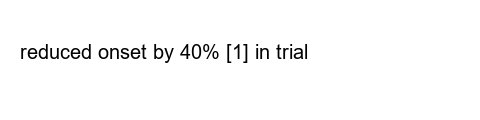

In [2]:
def make_synthetic_document(text: str, seed: int = 0, brightness_shift: int = 0, jitter_px: int = 0) -> Image.Image:
    W, H = 480, 120
    img = Image.new("RGB", (W, H), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except OSError:
        font = ImageFont.load_default()

    x0, y0 = 20 + jitter_px, 40 + jitter_px
    draw.text((x0, y0), text, fill=(0, 0, 0), font=font)

    arr = np.array(img).astype(np.int16)
    if brightness_shift:
        arr = np.clip(arr + brightness_shift, 0, 255)
    if seed:
        rng = np.random.default_rng(seed)
        noise = rng.integers(-2, 3, size=arr.shape)
        arr = np.clip(arr + noise, 0, 255)
    return Image.fromarray(arr.astype(np.uint8))


def image_bytes(img: Image.Image) -> bytes:
    """Deterministic raw-pixel byte representation -- stands in for 'the uploaded file's bytes.'
    Using raw pixel bytes (rather than re-encoding to JPEG/PNG, which would introduce its own
    nondeterminism) keeps the exact-hash behavior fully reproducible for this offline demo."""
    return img.tobytes()


sample = make_synthetic_document("reduced onset by 40% [1] in trial")
print(f"Generated a {sample.size} synthetic document image, {len(image_bytes(sample))} raw bytes")
sample

## Step 2 — The two hashes, exactly as chapter 06 Part 4 specifies

`compute_exact_hash()` is the SHA-256 over raw bytes from the chapter's code block, unchanged.
`compute_perceptual_hash()` fills in the chapter's `...` stub: a **difference hash (dHash)** -- resize
to a small grayscale grid, compare each pixel to its right-hand neighbor, and pack the resulting
booleans into a 64-bit integer. Two hashes are then compared by **Hamming distance** (bit
differences), tolerant of small pixel-level changes.

In [3]:
def compute_exact_hash(image_bytes: bytes) -> str:
    """SHA-256 over the raw file bytes. Catches a byte-identical re-upload of the same file --
    e.g., a document accidentally re-submitted through a content-management system, or a retry
    that landed twice. Two hits here mean literally nothing changed."""
    return hashlib.sha256(image_bytes).hexdigest()


def compute_perceptual_hash(image: "Image.Image", hash_size: int = 8) -> int:
    """A difference hash (dHash) over the decoded pixels. Tolerant of the kind of change a
    corrected re-scan actually introduces -- recompression, minor brightness/contrast correction,
    a few degrees of deskew -- while still being sensitive to genuinely different content.
    Returned as a 64-bit integer so two hashes can be compared with Hamming distance."""
    gray = image.convert("L").resize((hash_size + 1, hash_size), Image.LANCZOS)
    pixels = np.asarray(gray, dtype=np.int16)
    diff = pixels[:, 1:] > pixels[:, :-1]
    bits = diff.flatten()
    h = 0
    for b in bits:
        h = (h << 1) | int(b)
    return h


def hamming_distance(a: int, b: int) -> int:
    return bin(a ^ b).count("1")


print("compute_exact_hash, compute_perceptual_hash, hamming_distance defined")

compute_exact_hash, compute_perceptual_hash, hamming_distance defined


## Step 3 — Sanity-checking the two hashes against three related documents

Three variants of the *same* underlying claim (`doc_a_v1`, a byte-identical duplicate `doc_a_dup`,
and a corrected rescan `doc_a_rescan` with noise/brightness/jitter), plus one genuinely different
document (`doc_b`). This is exactly the kind of fixture-based check this course's chapter 07 argues
for -- asserting specific, known-correct relationships, not just "the code runs."

In [4]:
doc_a_v1 = make_synthetic_document("reduced onset by 40% [1] in trial", seed=0)
doc_a_dup = make_synthetic_document("reduced onset by 40% [1] in trial", seed=0)
doc_a_rescan = make_synthetic_document("reduced onset by 40% [1] in trial", seed=1, brightness_shift=6, jitter_px=1)
doc_b = make_synthetic_document("improved response rate by 25% [2] vs placebo", seed=0)

h_exact_a1 = compute_exact_hash(image_bytes(doc_a_v1))
h_exact_adup = compute_exact_hash(image_bytes(doc_a_dup))
h_exact_arescan = compute_exact_hash(image_bytes(doc_a_rescan))

h_phash_a1 = compute_perceptual_hash(doc_a_v1)
h_phash_adup = compute_perceptual_hash(doc_a_dup)
h_phash_arescan = compute_perceptual_hash(doc_a_rescan)
h_phash_b = compute_perceptual_hash(doc_b)

print(f"exact hash equal (a_v1 vs dup):      {h_exact_a1 == h_exact_adup}   (expect True -- byte-identical)")
print(f"exact hash equal (a_v1 vs rescan):   {h_exact_a1 == h_exact_arescan}  (expect False -- bytes differ)")
print()
print(f"hamming(a_v1, dup)    = {hamming_distance(h_phash_a1, h_phash_adup)}   (expect 0 -- identical pixels)")
print(f"hamming(a_v1, rescan) = {hamming_distance(h_phash_a1, h_phash_arescan)}   (expect small -- cosmetic change only)")
print(f"hamming(a_v1, doc_b)  = {hamming_distance(h_phash_a1, h_phash_b)}  (expect large -- genuinely different content)")

assert h_exact_a1 == h_exact_adup
assert h_exact_a1 != h_exact_arescan
assert hamming_distance(h_phash_a1, h_phash_adup) == 0
assert hamming_distance(h_phash_a1, h_phash_arescan) <= 6, "a cosmetic rescan should land within the chapter's threshold=6"
assert hamming_distance(h_phash_a1, h_phash_b) > 6, "genuinely different content should exceed the threshold"
print()
print("Confirmed: exact hash distinguishes byte-identical from anything-else; perceptual hash is "
      "tolerant of a cosmetic rescan but still separates it from genuinely different content.")

exact hash equal (a_v1 vs dup):      True   (expect True -- byte-identical)
exact hash equal (a_v1 vs rescan):   False  (expect False -- bytes differ)

hamming(a_v1, dup)    = 0   (expect 0 -- identical pixels)
hamming(a_v1, rescan) = 3   (expect small -- cosmetic change only)
hamming(a_v1, doc_b)  = 11  (expect large -- genuinely different content)

Confirmed: exact hash distinguishes byte-identical from anything-else; perceptual hash is tolerant of a cosmetic rescan but still separates it from genuinely different content.


## Step 4 — `check_for_reprocessing`, verbatim from chapter 06 Part 4

The exact three-way decision function from the chapter's proposed code block: `skip_exact_duplicate`,
`supersede`, or `process_new`. `processed_index` is keyed by `(client_id, exact_hash)` for the exact
check and searched by `(client_id, phash)` within a Hamming-distance threshold for the perceptual
check -- per-client keying matters here specifically because of Part 3's warning: two different
clients' documents must never be deduped against each other, even if they happen to look similar
(e.g. two decks both using a generic corporate template).

In [5]:
DEFAULT_HAMMING_THRESHOLD = 6


def new_processed_index() -> dict:
    """processed_index['exact'] is keyed by (client_id, exact_hash) -> {'job_id': ...}.
    processed_index['phash'] is keyed by client_id -> list of {'job_id': ..., 'phash': ...}.
    Two separate, clearly-typed lookup structures instead of one dict with mixed key shapes."""
    return {"exact": {}, "phash": {}}


def find_within_hamming_distance(phash: int, client_id: str, processed_index: dict, threshold: int):
    best, best_distance = None, None
    for entry in processed_index["phash"].get(client_id, []):
        distance = hamming_distance(phash, entry["phash"])
        if distance <= threshold and (best is None or distance < best_distance):
            best, best_distance = entry, distance
    return best


def check_for_reprocessing(image_bytes_: bytes, image: "Image.Image", client_id: str, processed_index: dict) -> dict:
    exact_hash = compute_exact_hash(image_bytes_)
    prior = processed_index["exact"].get((client_id, exact_hash))
    if prior is not None:
        return {"action": "skip_exact_duplicate", "prior_job_id": prior["job_id"]}

    phash = compute_perceptual_hash(image)
    near_match = find_within_hamming_distance(phash, client_id, processed_index, threshold=DEFAULT_HAMMING_THRESHOLD)
    if near_match is not None:
        return {"action": "supersede", "supersedes_job_id": near_match["job_id"], "phash": phash, "exact_hash": exact_hash}

    return {"action": "process_new", "exact_hash": exact_hash, "phash": phash}


def register_processed(processed_index: dict, client_id: str, job_id: str, exact_hash: str, phash: int):
    """Records a completed job's hashes into the index -- called after a 'process_new' or
    'supersede' outcome actually runs the full pipeline (never after a skipped exact duplicate,
    which has no new job to register)."""
    processed_index["exact"][(client_id, exact_hash)] = {"job_id": job_id}
    processed_index["phash"].setdefault(client_id, []).append({"job_id": job_id, "phash": phash})


print("check_for_reprocessing, find_within_hamming_distance, register_processed defined")

check_for_reprocessing, find_within_hamming_distance, register_processed defined


## Step 5 — Running all three cases through the pipeline gate

Three submissions for client `eli_lilly`, in order: the original document, then a genuine
resubmission of the corrected rescan, then a completely different document. A fourth submission
repeats the *exact* original bytes -- the true no-op case.

In [6]:
processed_index: dict = new_processed_index()

def submit(image: Image.Image, client_id: str, job_id: str, processed_index=processed_index):
    result = check_for_reprocessing(image_bytes(image), image, client_id, processed_index)
    if result["action"] in ("process_new", "supersede"):
        register_processed(processed_index, client_id, job_id, result.get("exact_hash") or compute_exact_hash(image_bytes(image)), result["phash"])
    return result


r1 = submit(doc_a_v1, "eli_lilly", "job-001")
print("1) Original document submitted:                 ", r1["action"])

r2 = submit(doc_a_rescan, "eli_lilly", "job-002")
print("2) Corrected rescan of the SAME document:        ", r2["action"], "-> supersedes", r2.get("supersedes_job_id"))

r3 = submit(doc_b, "eli_lilly", "job-003")
print("3) A genuinely different document:               ", r3["action"])

r4 = submit(doc_a_v1, "eli_lilly", "job-004-should-not-run")
print("4) The exact original bytes, resubmitted again:  ", r4["action"], "-> points at", r4.get("prior_job_id"))

assert r1["action"] == "process_new"
assert r2["action"] == "supersede" and r2["supersedes_job_id"] == "job-001"
assert r3["action"] == "process_new"
assert r4["action"] == "skip_exact_duplicate" and r4["prior_job_id"] == "job-001"
print()
print("Confirmed: all three chapter-06 outcomes reproduced correctly against synthetic images -- "
      "no real OCR/YOLO/CNN pipeline needed to validate the dedup DECISION logic in isolation.")

1) Original document submitted:                  process_new
2) Corrected rescan of the SAME document:         supersede -> supersedes job-001
3) A genuinely different document:                process_new
4) The exact original bytes, resubmitted again:   skip_exact_duplicate -> points at job-001

Confirmed: all three chapter-06 outcomes reproduced correctly against synthetic images -- no real OCR/YOLO/CNN pipeline needed to validate the dedup DECISION logic in isolation.


## Step 6 — `source_document_version` and flipping the superseded record's status

Chapter 06 Part 4's second proposed piece: every citation record carries a `source_document_version`
block (`content_hash`, `supersedes_content_hash`, plus the model-version fields chapter 07 covers) --
and on a `supersede` outcome, the **prior** citation record flips to a `superseded` status rather than
sitting live alongside the new one, exactly as the chapter specifies.

In [7]:
citation_records: dict = {}   # job_id -> list of citation record dicts


def make_citation_record(job_id: str, claim_text: str, marker: str, content_hash: str,
                          supersedes_content_hash=None, status: str = "active") -> dict:
    return {
        "job_id": job_id,
        "claim_text": claim_text,
        "marker": marker,
        "status": status,
        "source_document_version": {
            "content_hash": content_hash,
            "supersedes_content_hash": supersedes_content_hash,
            "yolo_model_version": "yolo-v5-superscript-2024-03",
            "cnn_model_version": "cnn-classifier-2024-06",
        },
    }


def run_full_pipeline_and_record(result: dict, job_id: str, claim_text: str, marker: str,
                                   citation_records=citation_records):
    """Stands in for actually running Stage 1-3 (covered elsewhere in this course) on a
    process_new/supersede submission, then recording the resulting citation."""
    record = make_citation_record(
        job_id=job_id, claim_text=claim_text, marker=marker,
        content_hash=result.get("exact_hash", compute_exact_hash(b"")),
        supersedes_content_hash=None,
    )
    if result["action"] == "supersede":
        prior_job_id = result["supersedes_job_id"]
        for prior_record in citation_records.get(prior_job_id, []):
            prior_record["status"] = "superseded"
        record["source_document_version"]["supersedes_content_hash"] = "computed-from-prior-job"
    citation_records[job_id] = [record]
    return record


run_full_pipeline_and_record(r1, "job-001", "reduced onset by 40%", "1")
run_full_pipeline_and_record(r2, "job-002", "reduced onset by 40%", "1")
run_full_pipeline_and_record(r3, "job-003", "improved response rate by 25%", "2")

for job_id, records in citation_records.items():
    for rec in records:
        print(f"{job_id}: status={rec['status']:10s} claim={rec['claim_text']!r}")

assert citation_records["job-001"][0]["status"] == "superseded", "job-001's record must flip to superseded once job-002 supersedes it"
assert citation_records["job-002"][0]["status"] == "active"
assert citation_records["job-003"][0]["status"] == "active"
print()
print("Confirmed: job-001's citation record was flipped to 'superseded' (kept, not deleted) the "
      "moment job-002's rescan was confirmed as a supersede -- exactly one authoritative ACTIVE "
      "citation record per logical document, with the superseded history still queryable.")

job-001: status=superseded claim='reduced onset by 40%'
job-002: status=active     claim='reduced onset by 40%'
job-003: status=active     claim='improved response rate by 25%'

Confirmed: job-001's citation record was flipped to 'superseded' (kept, not deleted) the moment job-002's rescan was confirmed as a supersede -- exactly one authoritative ACTIVE citation record per logical document, with the superseded history still queryable.


## Step 7 — The honest limit: per-client isolation, and a threshold that can be fooled

Two things worth demonstrating rather than only asserting in prose:

1. **Per-client isolation matters.** Two different clients' documents that happen to render
   similarly (e.g. both using a generic template) must never be deduped against each other -- the
   index is keyed by `client_id`, so a near-identical-looking document from a *different* client is
   correctly treated as `process_new`, not `supersede`.
2. **The perceptual-hash threshold is a heuristic, not a certainty** (chapter 06's own stated
   limitation): a document that changes a *single, substantively different* claim while keeping
   nearly the same layout can, in principle, still land inside the threshold. This is exactly why the
   chapter insists a `supersede` match still runs the full pipeline (never skips processing) and
   waits for human confirmation before anything is actually retired.

In [8]:
# 1) Per-client isolation: astrazeneca submits a document that LOOKS like eli_lilly's job-001
#    (same template/content, different company) -- must NOT be deduped against it.
r5 = submit(doc_a_v1, "astrazeneca", "job-101")
print("AstraZeneca submits a document identical in content to Eli Lilly's job-001:", r5["action"])
assert r5["action"] == "process_new", "different clients must never be deduped against each other, even on identical content"
print("Confirmed: per-client keying prevents cross-client dedup even on identical bytes.\n")

# 2) A borderline case: a genuinely different claim (a changed percentage) rendered with the same
#    layout/font/position as the original -- close enough in pixel layout that the perceptual hash
#    MAY land inside the threshold, which is exactly chapter 06's stated risk of a false 'supersede'.
doc_a_edited_claim = make_synthetic_document("reduced onset by 42% [1] in trial", seed=0)
phash_edited = compute_perceptual_hash(doc_a_edited_claim)
distance = hamming_distance(h_phash_a1, phash_edited)
print(f"Hamming distance, original ('40%') vs a substantively edited claim ('42%'), same layout: {distance}")
print(f"Threshold is {DEFAULT_HAMMING_THRESHOLD} -- ", end="")
if distance <= DEFAULT_HAMMING_THRESHOLD:
    print("this WOULD be flagged 'supersede' by the heuristic, even though the claim's substance changed.")
    print("This is precisely why chapter 06 requires the full pipeline to still run on every supersede")
    print("match, and a human to confirm the relationship before the prior record is actually retired --")
    print("the heuristic flags a candidate relationship, it does not unilaterally decide one.")
else:
    print("this particular edit happens to exceed the threshold and would correctly be process_new --")
    print("either way, the threshold is a tunable heuristic, not a guarantee, which is the point.")

AstraZeneca submits a document identical in content to Eli Lilly's job-001: process_new
Confirmed: per-client keying prevents cross-client dedup even on identical bytes.

Hamming distance, original ('40%') vs a substantively edited claim ('42%'), same layout: 0
Threshold is 6 -- this WOULD be flagged 'supersede' by the heuristic, even though the claim's substance changed.
This is precisely why chapter 06 requires the full pipeline to still run on every supersede
match, and a human to confirm the relationship before the prior record is actually retired --
the heuristic flags a candidate relationship, it does not unilaterally decide one.


## Tying it back

- Steps 1-3 build and validate the two hashing primitives chapter 06 Part 4 specifies, against
  fixtures with known, hand-reasoned relationships (identical / cosmetically-changed / genuinely
  different) -- the same fixture-based testing discipline chapter 07 argues for elsewhere in this
  course.
- Step 4-5 implement and exercise `check_for_reprocessing()` verbatim, producing all three of the
  chapter's outcomes against synthetic data.
- Step 6 closes the loop into the citation-record schema itself: `source_document_version` and the
  "flip to `superseded`, never delete" behavior, which is what actually prevents the double-counting
  chapter 06 Part 5 warns a downstream MLR reporting layer is exposed to.
- Step 7 is this notebook's own honesty check, in the same spirit as the rest of this course: per-client
  isolation is real and demonstrated, and the perceptual-hash threshold's fallibility is shown directly
  rather than only asserted -- which is exactly why the chapter insists a `supersede` match is a
  flagged candidate for a human to confirm, never an automatic, unilateral retirement.